

# Підготовка даних до аналізу






<h2>Мета</h2>

Ознайомитись з методикою первинної обробки даних. Після завершення цієї лабораторної роботи ви зможете:

* Досліджувати структуру завантажених даних
* Виправляти формати даних
* Знаходити та заповнювати пропуски в даних
* Знаходити викиди та некоректні значення
* Будувати прості візуалізації




<a name="task"></a>
<div class="alert alert-danger alertdanger" style="margin-top: 20px">

# <h1 id="task">Завдання, що оцінюються </h1>

</div>





1. Скачати дані із файлу, записати у dataframe. Дослідити структуру даних.
2. Виправити помилки в даних.
3. Побудувати діаграми розмаху та гістограми.
4. Заповнити пропуски.
5. Додати стовпчик із щільністю населення.



<a name="task1"></a>
<div class="alert alert-danger alertdanger" style="margin-top: 20px">

## <h2 id="task1">Завдання  #1: </h2>

<p>Дослідити структуру даних</p>
</div>


Зчитую дані з файлу у датафрейм


In [82]:
import pandas as pd
DATA_PATH = 'Data2.csv'
df = pd.read_csv(DATA_PATH, sep=';', encoding='cp1252')

<details><summary>Натисніть тут, щоб побачити підказку</summary>

```python
DATA_PATH = 'data/Data2.csv'

# Зчитуємо файл із заданим розділяючим символом ";"
df = pd.read_csv(DATA_PATH, sep=';')

'''
Зауваження: попередній код зчитування з файлу підходить для
файлів з кодуванням utf-8. Проте файл Data2.csv спочатку мав інше
кодування. Дане кодування потрібно вказати в якості параметру:
    
'''

df = pd.read_csv(DATA_PATH, sep=';', encoding='cp1252')


```
</details>




Досліджую структуру даних


In [83]:
df.head(10)

,Country Name,Region,GDP per capita,Populatiion,CO2 emission,Area
0,Afghanistan,South Asia,"561,7787463",34656032.0,"9809,225",652860
1,Albania,Europe & Central Asia,"4124,98239",2876101.0,"5716,853",28750
2,Algeria,Middle East & North Africa,"3916,881571",40606052.0,"145400,217",2381740
3,American Samoa,East Asia & Pacific,"11834,74523",55599.0,NaN,200
4,Andorra,Europe & Central Asia,"36988,62203",77281.0,"462,042",470
5,Angola,Sub-Saharan Africa,"3308,700233",28813463.0,"34763,16",1246700
6,Antigua and Barbuda,Latin America & Caribbean,"14462,17628",100963.0,"531,715",440
7,Argentina,Latin America & Caribbean,"12440,32098",43847430.0,"204024,546",2780400
8,Armenia,Europe & Central Asia,"3614,688357",2924816.0,"5529,836",29740
9,Aruba,Latin America & Caribbean,NaN,104822.0,"872,746",180


In [84]:
df.columns

Index(['Country Name', 'Region', 'GDP per capita', 'Populatiion',
       'CO2 emission', 'Area'],
      dtype='str')

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 217 entries, 0 to 216
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Country Name    217 non-null    str    
 1   Region          217 non-null    str    
 2   GDP per capita  190 non-null    str    
 3   Populatiion     216 non-null    float64
 4   CO2 emission    205 non-null    str    
 5   Area            216 non-null    str    
dtypes: float64(1), str(5)
memory usage: 10.3 KB


In [6]:
df.describe(include="all")

,Country Name,Region,GDP per capita,Populatiion,CO2 emission,Area
count,217,217,190,2.160000e+02,205,216
unique,217,7,190,NaN,202,212
top,Afghanistan,Europe & Central Asia,"561,7787463",NaN,"495,045",460
freq,1,58,1,NaN,2,3
mean,NaN,NaN,NaN,4.338952e+07,NaN,NaN
std,NaN,NaN,NaN,1.879574e+08,NaN,NaN
min,NaN,NaN,NaN,1.109700e+04,NaN,NaN
25%,NaN,NaN,NaN,7.900265e+05,NaN,NaN
50%,NaN,NaN,NaN,6.318988e+06,NaN,NaN
75%,NaN,NaN,NaN,2.380373e+07,NaN,NaN


In [7]:
df.isna().sum()

Country Name       0
Region             0
GDP per capita    27
Populatiion        1
CO2 emission      12
Area               1
dtype: int64

In [8]:
df.apply(lambda x: x.astype(str).str.startswith("-").any())

Country Name      False
Region            False
GDP per capita     True
Populatiion       False
CO2 emission      False
Area               True
dtype: bool

In [9]:
df["Area"].str.contains(',|\\.').sum()

np.int64(3)

In [86]:
df.loc[df['Populatiion'].idxmax()]

Country Name                     Latvia
Region            Europe & Central Asia
GDP per capita              14071,02723
Populatiion                1960424000.0
CO2 emission                   6974,634
Area                              64490
Name: 108, dtype: object

Бачу наступні проблеми в даних:
1. В назві колонки "Population" зайва літера і
2. Неправильні типи даних колонок "GDP per capita", "CO2 emission" та "Area" (str). Для проведення необхідного аналізу,типи перших двох потрібно привести до типу float64, а "Area" до int64, оскільки більшість значень цієї колонки є цілими числами (окрім 3, які можна буде округлити)
3. В колонках "GDP per capita" та "Area" присутні від'ємні значення. Населення Латвії є занадто великим та не відповідає дійсності
4. Є пропущені значення в ознаках колонок "GDP per capita", "Population", "CO2 emission" та "Area"

<a name="task2"></a> <div class="alert alert-danger alertdanger" style="margin-top: 20px">

## <h2 id="task2"> Завдання  #2: </h2>

<p>Виправити помилки в даних</p>
</div>


<b>Проблема 1. Неправильні назви</b>
<p>
    Для виправлення перейменую колонку "Populatiion" на "Population" за допомогою методу .rename
</p>
<p>   Перевіряю результат.</p>

In [87]:
# Напишіть ваш код нижче та натисніть Shift+Enter для виконання
df = df.rename(columns={"Populatiion": "Population"})
df.columns

Index(['Country Name', 'Region', 'GDP per capita', 'Population',
       'CO2 emission', 'Area'],
      dtype='str')

<b>Проблема 2. Неправильні типи даних</b>
<p>
    Відкрию файл даних поряд у вікні текстового редактора і постараюсь розібратись, чому типи даних визначились неправильно. 
    Проблемою стало використання ',' замість '.' в значеннях колонок "GDP per capita", "Area" та "CO2 emission"</p>
<p>Для виправлення заміню коми на крапку в усіх значеннях цих колонок та приведу до типу float64, а для "Area" можна використати regex для видалення будь яких символів після коми, після чого привести колонку до типу int64. Для коректного переведення використаємо саме тип Int64, який підтримує значення NaN
</p>
<p>   Перевіряю результат.</p>

In [89]:
# Напишіть ваш код нижче та натисніть Shift+Enter для виконання
df['CO2 emission'] =  df['CO2 emission'].str.replace(",", ".").astype('float64')
df['GDP per capita'] =  df['GDP per capita'].str.replace(",", ".").astype('float64')
df['Area'] = df['Area'].replace(r',.*', '', regex=True).astype('Int64')

In [90]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 217 entries, 0 to 216
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Country Name    217 non-null    str    
 1   Region          217 non-null    str    
 2   GDP per capita  190 non-null    float64
 3   Population      216 non-null    float64
 4   CO2 emission    205 non-null    float64
 5   Area            216 non-null    Int64  
dtypes: Int64(1), float64(3), str(2)
memory usage: 10.5 KB


<b>Проблема 3. Неправильні значення (занадто великі або занадто малі)</b>
<p>

Для виправлення зроблю наступне: Перевіривши площу М'янми на https://en.wikipedia.org/wiki/Myanmar, модуль значення в датафреймі практично співпадає із реальним значенням площі (676,579 кв. км), тому за допомогою .abs() встановлюємо правильне значення площі.

Наступним кроком потрібно виправити значеня "GDP per capita" для Домініканської Республіки. Проаналізувавши ВВП на душу населення цієї країни та близько десяти інших на сайті https://www.macrotrends.net/global-metrics/countries/ranking/gdp-per-capita, можна побачити що дані були взяті приблизно в проміжку між 2008 та 2015. Модуль ВВП на душу населення Домініканської Республіки у датафреймі відповідає значенню ВВП на душу населення у 2014 році, тому доцільним буде так само застосувати .abs() для взяття модуля цього значення

Для населення Латвії знайду дійсне значення населення за 2014 рік (відповідає встановленому вище проміжку часу збору даних)

Перевіряю результат.
</p>

In [91]:
# Напишіть ваш код нижче та натисніть Shift+Enter для виконання
df.loc[df['Country Name'] == "Myanmar", "Area"] = df.loc[df['Country Name'] == "Myanmar", "Area"].abs()
df.loc[df['Country Name'] == "Dominican Republic", "GDP per capita"] = df.loc[df['Country Name'] == "Dominican Republic", "GDP per capita"].abs()
df.loc[df['Country Name'] == "Latvia", "Population"] = 1994149

In [92]:
df.loc[df['Country Name'] == "Dominican Republic", "GDP per capita"]

56    6722.223536
Name: GDP per capita, dtype: float64

In [93]:
df.loc[df['Country Name'] == "Myanmar", "Area"]

135    676590
Name: Area, dtype: Int64

In [94]:
df.loc[df['Country Name'] == "Latvia", "Population"]

108    1994149.0
Name: Population, dtype: float64

<a name="task3"></a>
 <div class="alert alert-danger alertdanger" style="margin-top: 20px">

## <h2 id="task5"> Завдання  #3: </h2>

<p>Побудувати діаграми розмаху та гістограми</p>
</div>


Для побудови графіків скористайтесь бібліотекою Matplotlib. Спробуйте погратись з кольорами, розмірами та підписами.


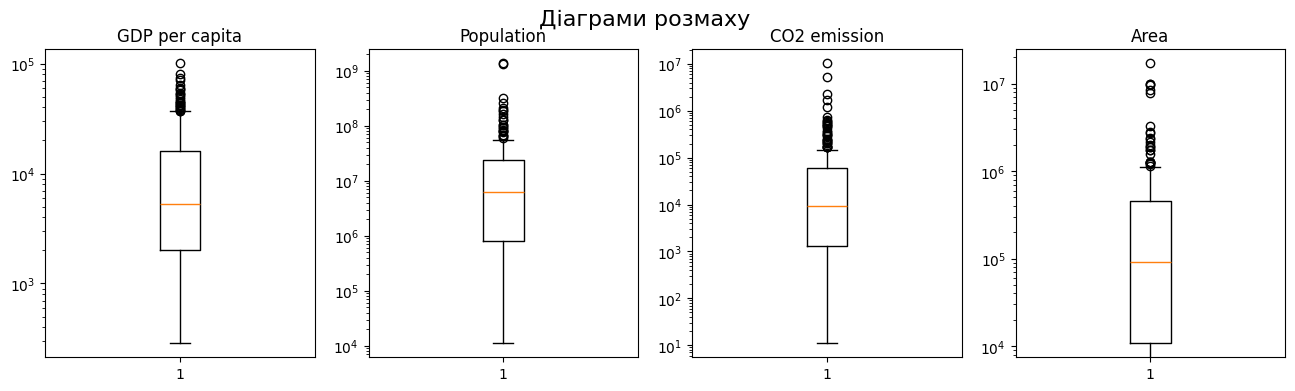

In [95]:
# Напишіть ваш код нижче та натисніть Shift+Enter для виконання
import matplotlib.pyplot as plt
fig, axs = plt.subplots(1, 4, figsize=(16, 4))

fig.suptitle('Діаграми розмаху', fontsize=16)

axs[0].set_title('GDP per capita')
axs[0].boxplot(df['GDP per capita'].dropna())
axs[0].set_yscale('log')

axs[1].set_title('Population')
axs[1].boxplot(df['Population'].dropna())
axs[1].set_yscale('log')

axs[2].set_title('CO2 emission')
axs[2].boxplot(df['CO2 emission'].dropna())
axs[2].set_yscale('log')

axs[3].set_title('Area')
axs[3].boxplot(df['Area'].dropna())
axs[3].set_yscale('log')

plt.show()

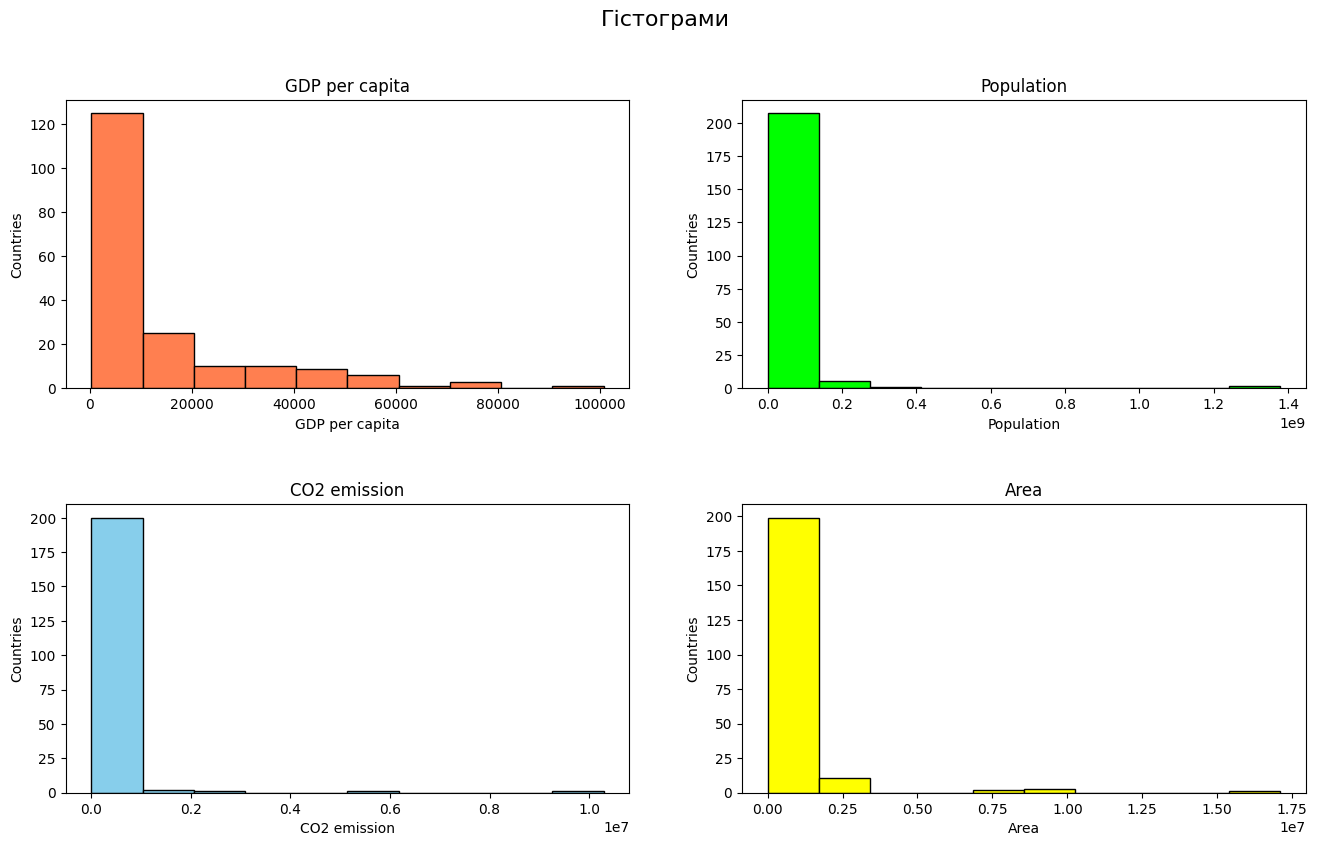

In [96]:
fig, axs = plt.subplots(2,2, figsize=(16, 9))
fig.suptitle("Гістограми", fontsize=16)

axs[0][0].set_title('GDP per capita')
axs[0][0].hist(df['GDP per capita'].dropna(), color="coral", edgecolor="black")
axs[0][0].set_xlabel('GDP per capita')
axs[0][0].set_ylabel('Countries')

axs[0][1].set_title('Population')
axs[0][1].hist(df['Population'].dropna(), color="lime", edgecolor="black")
axs[0][1].set_xlabel('Population')
axs[0][1].set_ylabel('Countries')

axs[1][0].set_title('CO2 emission')
axs[1][0].hist(df['CO2 emission'].dropna(), color="skyblue", edgecolor="black")
axs[1][0].set_xlabel('CO2 emission')
axs[1][0].set_ylabel('Countries')

axs[1][1].set_title('Area')
axs[1][1].hist(df['Area'].dropna(), color="yellow", edgecolor="black")
axs[1][1].set_xlabel('Area')
axs[1][1].set_ylabel('Countries')

plt.subplots_adjust(wspace=0.2, hspace=0.4)
plt.show()

<details><summary>Натисніть тут, щоб побачити підказку</summary>

```python
# Імпортуємо бібліотеку Matplotlib
import matplotlib.pyplot as plt
    
# діаграми розмаху для "GDP per capita", "Population", "CO2 emission" та "Area"

fig, axs = plt.subplots(1, 4, figsize=(16, 4))

fig.suptitle('Діаграми розмаху', fontsize=16)

axs[0].set_title('GDP per capita')
axs[0].boxplot(df['GDP per capita'])

axs[1].set_title('Population')
axs[1].boxplot(df['Population'])

axs[2].set_title('CO2 emission')
axs[2].boxplot(df['CO2 emission'])

axs[3].set_title('Area')
axs[3].boxplot(df['Area'])

plt.show()

```
</details>




<a name="task4"></a>
<div class="alert alert-danger alertdanger" style="margin-top: 20px">

## <h2 id="task3"> Завдання  #4: </h2>
<b>Проблема 4. Пропущені значення </b>
<p>Як найкраще заповнити пропуски підкажуть візуалізації з попереднього завдання.</p>
</div>


Для одного пропущеного значення в колонці "Area" просто знайду відповідне значення площі в інтернеті, оскільки це швидко та повністю точно.Так само можна зробити і для значення в колонці "Population". Дані для населення Еритреї візьму за 2014 рік, щоб зберегти загальну цілісність даних

Для колонок "CO2 emission" та "GDP per capita" пропущені значення заповню медіаною відповідної ознаки для регіону

In [97]:
print(df[df['Area'].isna()]['Country Name'])

49    Cuba
Name: Country Name, dtype: str


In [98]:
# Напишіть ваш код нижче та натисніть Shift+Enter для виконання
# Окрім того, я побачив, що у Bermuda площа початково була нулем, а не NaN,
# тому також вирішив це виправити, знайшовши інформацію про її площу
df.loc[df['Country Name'] == "Cuba", "Area"] = 110860
df.loc[df['Country Name'] == "Bermuda", "Area"] = 54

In [99]:
print(df[df['Population'].isna()]['Country Name'])

61    Eritrea
Name: Country Name, dtype: str


In [100]:
df['Population'] = df['Population'].fillna(3095173)

In [101]:
#Для CO2
df['CO2 emission'] = df['CO2 emission'].fillna(df.groupby('Region')['CO2 emission'].transform("median"))
#Для GDP
df['GDP per capita'] = df['GDP per capita'].fillna(df.groupby('Region')['GDP per capita'].transform("median"))

Досліджую структуру даних, чи всі пропуски заповнено


In [102]:
# Напишіть ваш код нижче та натисніть Shift+Enter для виконання
df.isna().sum()

Country Name      0
Region            0
GDP per capita    0
Population        0
CO2 emission      0
Area              0
dtype: int64

 <a name="task5"></a>
 <div class="alert alert-danger alertdanger" style="margin-top: 20px">

## <h2 id="task4"> Завдання  #5: </h2>

<p>Додати стовпчик із щільністю населення</p>
</div>


Щільність населення розрахую по формулі density = population/area і додам у стовпчик "Population density".


In [103]:
# Напишіть ваш код нижче та натисніть Shift+Enter для виконання
df['Population density'] = df['Population'] / df['Area']
df.head()

,Country Name,Region,GDP per capita,Population,CO2 emission,Area,Population density
0,Afghanistan,South Asia,561.778746,34656032.0,9809.225,652860,53.083405
1,Albania,Europe & Central Asia,4124.982390,2876101.0,5716.853,28750,100.038296
2,Algeria,Middle East & North Africa,3916.881571,40606052.0,145400.217,2381740,17.048902
3,American Samoa,East Asia & Pacific,11834.745230,55599.0,6501.591,200,277.995
4,Andorra,Europe & Central Asia,36988.622030,77281.0,462.042,470,164.42766


<a name="task6"></a>
 <div class="alert alert-success alertsuccess" style="margin-top: 20px">

## <h2 id="task6"> Додаткове завдання: </h2>

<p>Дайте відповіді на питання</p>
</div>



1. Яка країна має найменшу площу?
2. Знайдіть країну з найбільшою щільністю населення у світі? У Європі та центральній Азії?
3. Яка країна має найбільший ВВП на людину (GDP per capita)?
4. Покажіть топ 5 країн та 5 останніх країн по ВВП на людину.



<details><summary>Натисніть тут, щоб побачити підказку</summary>
    
Скористайтесь методами <code>loc()</code> для повернення зрізу датафрейму, <code>idxmax()</code> для повернення номера рядка з найбільшим значенням якогось показника у стовпці та <code>idxmin()</code> для повернення номера рядка з найменшим значенням якогось показника у стовпці
    
```python
df.loc[df['GDP per capita'].idxmax()]

```
    
Гарно оформити виведення інформації допоможе <code>print()</code>  
```python
print('\n' + df.loc[df['GDP per capita'].idxmax(), 'Country Name'] + ' має найбільший ВВП на людину')
```   
  
</details>


In [104]:
# Напишіть ваш код нижче та натисніть Shift+Enter для виконання
print("Smallest area: " + df.loc[df['Area'].idxmin(), "Country Name"])
print("Largest population density in the world: " + df.loc[df['Population density'].idxmax(), "Country Name"])
print("Largest population density in Europe & Central Asia: " + df.loc[df[df['Region'] == 'Europe & Central Asia']['Population density'].idxmax(), 'Country Name'])
print("Largest GDP per capita in the world: " + df.loc[df['GDP per capita'].idxmax(), "Country Name"])
print("\nTop 5 by GDP:")
print(df.nlargest(5, columns=['GDP per capita'])[['Country Name', 'GDP per capita']])
print("\nBottom 5 by GDP:")
print(df.nsmallest(5, columns=['GDP per capita'])[['Country Name', 'GDP per capita']])

Smallest area: Monaco
Largest population density in the world: Macao SAR, China
Largest population density in Europe & Central Asia: Monaco
Largest GDP per capita in the world: Luxembourg

Top 5 by GDP:
         Country Name  GDP per capita
115        Luxembourg    100738.68420
188       Switzerland     79887.51824
116  Macao SAR, China     74017.18471
146            Norway     70868.12250
92            Ireland     64175.43824

Bottom 5 by GDP:
                 Country Name  GDP per capita
31                    Burundi      285.727442
119                    Malawi      300.307665
134                Mozambique      382.069330
37   Central African Republic      382.213174
118                Madagascar      401.742270


Збережіть дані у новий файл 'clean_data.csv':


In [105]:
# Напишіть ваш код нижче та натисніть Shift+Enter для виконання
df.to_csv("clean_data.csv")

<h2>Виконав студент групи ІП-44  <br>Комін Іван</h2>
